In [1]:
import pandas as pd
import geopandas as geopd
#import geopandas as geopd

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"]  = 400
plt.style.use('dark_background')

In [2]:
flows = pd.read_parquet("flow/all_flows.parquet")
places = geopd.read_file('flow/measurement_locations.gpkg', layer="all")

In [6]:
""" CORINE is only available in Finland from 2000 onwards.
If that dataset is used backwards to 1995, we can get 30 years reference period.
I think five years is still quite reasonable, but I'm not really willing to go backwards more.
"""
clipped_flows = flows['1994-01-01':'2023-12-31']
clipped_flows = clipped_flows.dropna(axis=1, how='all')
# Stations 3748 and 2723 measure the artificial bifurcation of Perhonjoki. Thus a virtual measurement station named 6471 is created
clipped_flows['6471'] = clipped_flows['2723'] + clipped_flows['3748']

# Stations 2687 and 3160 measure the artificial bifurcation of Perhonjoki. Thus a virtual measurement station named 5847 is created
clipped_flows['5847'] = clipped_flows['2687'] + clipped_flows['3160']

In [7]:
clipped_flows.to_parquet("flow/flows_from_1994.parquet")

In [45]:
clipped_index = clipped_flows.columns
clipped_places = places.loc[places['Paikka_Id'].isin(clipped_index)]

In [50]:
clipped_places.to_file('flow/measurement_locations.gpkg', driver="GPKG", layer="from_1995")

### For Sadegh

In [24]:
sadegh_flows = flows['1961-01-01':'2023-12-31']
sadegh_flows = sadegh_flows.dropna(axis=1, thresh=1150)
sadegh_index = sadegh_flows.columns
sadegh_places = places.loc[places['Paikka_Id'].isin(sadegh_index)]
sadegh_flows.to_parquet("flow/flows_from_1961.parquet")
sadegh_places.to_file('flow/measurement_locations_sadegh.gpkg', driver="GPKG", layer="from_1961")

In [23]:
sadegh_flows

,894,895,896,897,898,899,900,901,903,904,...,3794,3814,3850,3851,3872,3875,3907,3915,3945,3975
datetime,,,,,,,,,,,,,,,,,,,,,
1961-01-01,9.70,NaN,NaN,NaN,NaN,NaN,NaN,30.00,21.80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-02,10.10,NaN,NaN,NaN,NaN,NaN,NaN,30.00,33.50,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-03,10.30,NaN,NaN,NaN,NaN,NaN,NaN,30.00,37.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-04,10.40,NaN,NaN,NaN,NaN,NaN,NaN,30.00,39.30,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-05,10.60,NaN,NaN,NaN,NaN,NaN,NaN,30.00,39.20,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,12.58,20.22,4.00,8.02,NaN,NaN,6.60,80.74,104.54,NaN,...,0.35,NaN,2.80,0.96,19.79,6.83,NaN,0.21,8.34,5.33
2023-12-28,13.87,16.94,3.90,8.02,NaN,NaN,6.56,80.40,101.37,NaN,...,0.35,NaN,2.17,0.95,19.84,7.01,NaN,0.20,8.35,5.43
2023-12-29,12.77,13.38,3.84,8.02,NaN,NaN,6.56,80.06,99.20,NaN,...,0.40,NaN,1.50,0.93,19.68,4.11,NaN,0.20,8.27,5.49


<Axes: >

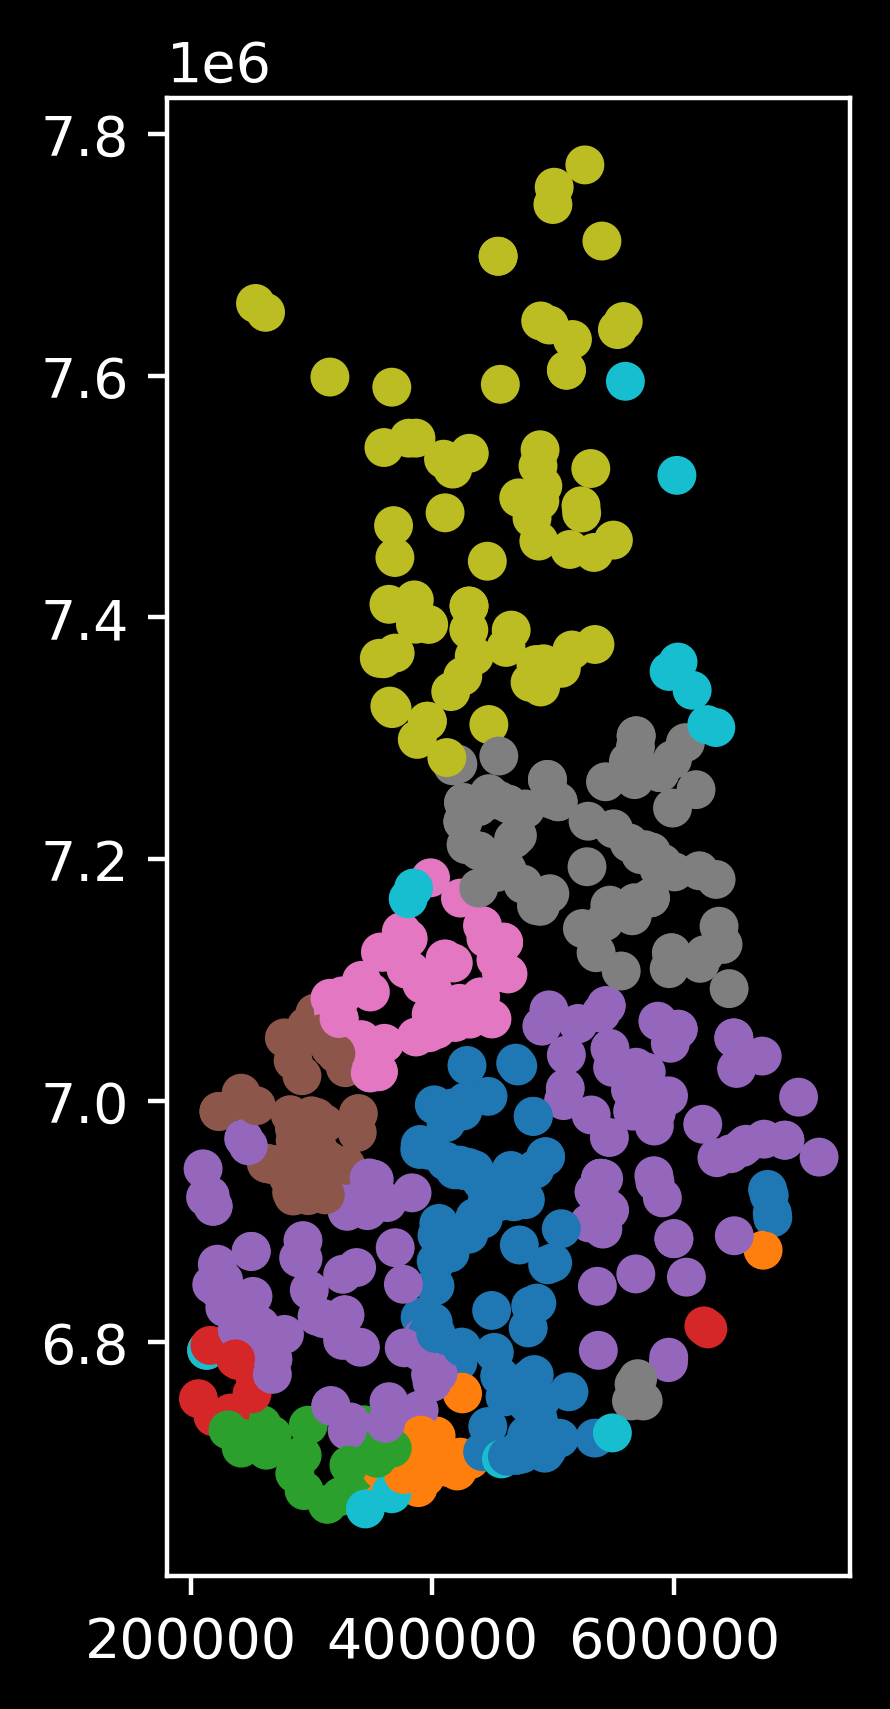

In [22]:
sadegh_places.plot("H_PaaVesal_Id")

In [5]:
clipped_flows

,894,895,896,897,898,900,901,903,905,907,...,3944,3945,3952,3955,3956,3957,3960,3975,6471,5847
datetime,,,,,,,,,,,,,,,,,,,,,
1995-01-01,8.40,9.40,3.54,6.20,9.4,5.54,63.19,86.00,3.52,2.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-02,15.80,16.70,3.52,6.20,9.4,5.73,62.35,85.00,4.06,1.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-03,15.80,15.30,3.46,6.20,9.4,5.83,62.28,83.00,4.45,1.95,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-04,15.30,17.10,3.43,6.20,9.4,5.89,61.99,77.00,5.36,1.93,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-05,14.20,15.50,3.39,6.20,9.3,5.97,60.74,81.00,5.62,1.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,12.58,20.22,4.00,8.02,NaN,6.60,80.74,104.54,3.84,1.55,...,0.33,8.34,0.19,6.62,NaN,NaN,0.0,5.33,0.90,1.79
2023-12-28,13.87,16.94,3.90,8.02,NaN,6.56,80.40,101.37,3.79,1.54,...,0.32,8.35,0.19,6.57,NaN,NaN,0.0,5.43,0.90,2.68
2023-12-29,12.77,13.38,3.84,8.02,NaN,6.56,80.06,99.20,3.74,1.51,...,0.31,8.27,0.19,6.28,NaN,NaN,0.0,5.49,0.88,2.60


In [18]:
places

,Paikka_Id,Suure_Id,H_Kunta_Id,KuntaNimi,Nro,Nimi,KoordYkPohj,KoordYkIta,KoordPkPohj,KoordPkIta,...,H_Vesal_Id,VesalNimi,H_PaaVesal_Id,PaaVesalNimi,KoordErTmPohj,KoordErTmIta,Jarvi_Id,JarviNro,JarviNimi,geometry
0,894,2,167,Joensuu,0100150,Ruskeakoski,6929395,3677929,6924731,4522990,...,10,Loitimon la,1,Jänisjoki,6926492,677686,93,01.021.1.001,Melakko-Loitimo,POINT (677686 6926492)
1,895,2,848,Tohmajärvi,0101251,Vääräkoski,6905869,3682250,6901039,4526215,...,4,Jänisjoen keskiosan a,1,Jänisjoki,6902976,682005,18,01.011.1.018,Varislampi,POINT (682005 6902976)
2,896,2,260,Kitee,0201000,Kontturi,6879031,3674209,6874612,4516944,...,69,Kiteenjoen alaosan a,2,Tohmajoki,6876149,673968,742,02.021.1.001,Kamarahkonlampi,POINT (673968 6876149)
3,897,2,689,Rautjärvi,0300250,Juankoski,6816330,3625189,6814253,4465100,...,81,Simpelejärven alaosan la,3,Hiitolanjoki,6813473,624968,835,03.012.1.020,Konkanlampi,POINT (624968 6813473)
4,898,2,689,Rautjärvi,0300450,Kangaskoski,6813860,3628467,6811636,4468260,...,78,Kokkolanjoen a,3,Hiitolanjoki,6811004,628245,813,03.011.1.001,Lahnanen,POINT (628245 6811004)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668,3956,2,734,Salo,2400402,"Kiskonjoki, Koski, kalatie",6680140,3294451,6674512,2460841,...,1496,Kirkkojärven la,24,Kiskonjoki + Perniönjoki,6677336,294365,None,None,None,POINT (294365 6677336)
669,3957,2,271,Kokemäki,3509870,Piilijoki,6818330,3261143,6811026,2421306,...,1717,Piilijoen a,35,Kokemäenjoki,6815469,261070,None,None,None,POINT (261070 6815469)
670,3960,2,288,Kruunupyy,4900354,Kaitfors kalatie lisävesitysputki,7070682,3323333,7065869,2471678,...,2654,Paasilan a,49,Perhonjoki,7067720,323233,None,None,None,POINT (323233 7067720)
671,3968,2,288,Kruunupyy,4802000,Djupsjön,7049594,3331063,7045174,2480385,...,2640,Peckassjön a,48,Kruunupyynjoki,7046640,330960,25355,48.004.1.001,Djupsjön,POINT (330960 7046640)


In [5]:
def temp_class(temp):
    if 
    if temp >= 2 and temp < 15:
        return(2)
    else:
        return(3)
print(temp_class(2))

2


In [9]:
test_list = [2,1,3]
sorted_list = sorted(test_list)
print(sorted_list)

[1, 2, 3]


In [10]:
'2003' == "2003"

True